# 04_data_preparation_and_modelling_final

Notebook นี้ใช้สำหรับทำ **Data Preparation** และ **Modelling** ของโปรเจกต์ Welly AI แบบจบในไฟล์เดียว  
โดยใช้ข้อมูลอาหารจาก `FOOD-DATA-GROUP1.csv` ถึง `FOOD-DATA-GROUP5.csv`

## เป้าหมาย
- รวม dataset หลักของอาหาร
- ทำความสะอาดข้อมูล
- จัดการ missing values
- สร้าง feature จากเกณฑ์โภชนาการ
- สร้าง `risk_level` แบบ rule-based
- ทดลอง baseline models
- บันทึกผลลัพธ์ไว้ใน `../outputs/`


## 1. Import Libraries

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
plt.rcParams["figure.figsize"] = (10, 6)


## 2. Load and Combine Food Datasets

In [2]:
group_files = [
    "../data/FOOD-DATA-GROUP1.csv",
    "../data/FOOD-DATA-GROUP2.csv",
    "../data/FOOD-DATA-GROUP3.csv",
    "../data/FOOD-DATA-GROUP4.csv",
    "../data/FOOD-DATA-GROUP5.csv",
]

for f in group_files:
    print(f, "->", os.path.exists(f))

missing_files = [f for f in group_files if not os.path.exists(f)]
if missing_files:
    raise FileNotFoundError(f"ไม่พบไฟล์เหล่านี้: {missing_files}")

df_list = [pd.read_csv(f) for f in group_files]
df = pd.concat(df_list, ignore_index=True)

print("Combined shape:", df.shape)
df.head()


../data/FOOD-DATA-GROUP1.csv -> True
../data/FOOD-DATA-GROUP2.csv -> True
../data/FOOD-DATA-GROUP3.csv -> True
../data/FOOD-DATA-GROUP4.csv -> True
../data/FOOD-DATA-GROUP5.csv -> True
Combined shape: (2395, 37)


,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,Cholesterol,Sodium,Water,Vitamin A,Vitamin B1,Vitamin B11,Vitamin B12,Vitamin B2,Vitamin B3,Vitamin B5,Vitamin B6,Vitamin C,Vitamin D,Vitamin E,Vitamin K,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,0,0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,0.9,0.0,14.6,0.016,7.6,0.200,0.033,0.064,0.092,0.097,0.084,0.052,0.096,0.004,0.000,0.000,0.100,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,1,1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,7.8,0.0,62.9,0.300,53.6,0.200,0.099,0.079,0.090,0.100,0.200,0.500,0.078,0.000,0.000,0.300,0.045,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,2,2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,0.8,0.1,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,3,3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,1.5,0.0,9.8,0.017,14.7,0.075,0.019,0.079,0.091,0.027,0.041,0.016,0.007,0.006,0.000,0.001,0.011,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,4,4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,1.2,0.0,8.1,0.046,10.0,0.016,0.080,0.062,0.049,0.026,0.080,0.100,0.003,0.000,0.036,0.009,0.019,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007


## 3. Data Overview

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (2395, 37)

Columns:
['Unnamed: 0.1', 'Unnamed: 0', 'food', 'Caloric Value', 'Fat', 'Saturated Fats', 'Monounsaturated Fats', 'Polyunsaturated Fats', 'Carbohydrates', 'Sugars', 'Protein', 'Dietary Fiber', 'Cholesterol', 'Sodium', 'Water', 'Vitamin A', 'Vitamin B1', 'Vitamin B11', 'Vitamin B12', 'Vitamin B2', 'Vitamin B3', 'Vitamin B5', 'Vitamin B6', 'Vitamin C', 'Vitamin D', 'Vitamin E', 'Vitamin K', 'Calcium', 'Copper', 'Iron', 'Magnesium', 'Manganese', 'Phosphorus', 'Potassium', 'Selenium', 'Zinc', 'Nutrition Density']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2395 entries, 0 to 2394
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0.1          2395 non-null   int64  
 1   Unnamed: 0            2395 non-null   int64  
 2   food                  2395 non-null   str    
 3   Caloric Value         2395 non-null   int64  
 4   Fat                   2395 non-null   float64
 5   Saturated Fats        2395 non-null   float64
 6   Monounsaturated Fats  2395 non-null   float64
 7   Polyunsaturated Fats  2395 non-null   float64
 8   Carbohydrates         2395 non-null   float64
 9   Sugars                2395 non-null   float64
 10  Protein               2395 non-null   float64
 11  Dietary Fiber         2395 non-null   float64
 12  Cholesterol           2395 non-null   float64
 13  Sodium                2395 non-null   float64
 14  Water                 2395 non-null   float64
 15  Vitamin A             2395 non-n

In [5]:
df.isnull().sum().sort_values(ascending=False)

Unnamed: 0.1            0
Vitamin B2              0
Vitamin B5              0
Vitamin B6              0
Vitamin C               0
Vitamin D               0
Vitamin E               0
Vitamin K               0
Calcium                 0
Copper                  0
Iron                    0
Magnesium               0
Manganese               0
Phosphorus              0
Potassium               0
Selenium                0
Zinc                    0
Vitamin B3              0
Vitamin B12             0
Unnamed: 0              0
Vitamin B11             0
food                    0
Caloric Value           0
Fat                     0
Saturated Fats          0
Monounsaturated Fats    0
Polyunsaturated Fats    0
Carbohydrates           0
Sugars                  0
Protein                 0
Dietary Fiber           0
Cholesterol             0
Sodium                  0
Water                   0
Vitamin A               0
Vitamin B1              0
Nutrition Density       0
dtype: int64

## 4. Standardize and Select Columns

ในขั้นนี้จะพยายาม map ชื่อคอลัมน์ของ dataset ให้กลายเป็นชื่อมาตรฐาน  
เพื่อให้สามารถใช้กับขั้น Data Preparation และ Modelling ต่อได้ง่าย


In [6]:
df.columns = [c.strip() for c in df.columns]

column_map_candidates = {
    "food_name": ["Food", "food", "Food Name", "food_name", "item", "Item", "Dish", "Description"],
    "calories": ["Caloric Value", "Calories", "calories", "Energy", "energy", "kcal"],
    "fat": ["Fat", "Total Fat", "fat"],
    "sat_fat": ["Saturated Fats", "Saturated Fat", "sat_fat"],
    "carbs": ["Carbohydrates", "Total Carbohydrate", "carbs", "Carbohydrate"],
    "sugar": ["Sugars", "Sugar", "sugar"],
    "protein": ["Protein", "protein"],
    "fiber": ["Dietary Fiber", "Fiber", "fiber"],
    "cholesterol": ["Cholesterol", "cholesterol"],
    "sodium": ["Sodium", "sodium"]
}

resolved_columns = {}
for std_name, options in column_map_candidates.items():
    found = None
    for opt in options:
        if opt in df.columns:
            found = opt
            break
    resolved_columns[std_name] = found

resolved_columns


{'food_name': 'food',
 'calories': 'Caloric Value',
 'fat': 'Fat',
 'sat_fat': 'Saturated Fats',
 'carbs': 'Carbohydrates',
 'sugar': 'Sugars',
 'protein': 'Protein',
 'fiber': 'Dietary Fiber',
 'cholesterol': 'Cholesterol',
 'sodium': 'Sodium'}

In [7]:
required_numeric = ["calories", "fat", "sat_fat", "carbs", "protein", "cholesterol", "sodium"]
missing_required = [c for c in required_numeric if resolved_columns.get(c) is None]

if missing_required:
    raise ValueError(f"คอลัมน์สำคัญยังหาไม่เจอ: {missing_required}\nกรุณาตรวจชื่อคอลัมน์จากผลลัพธ์ด้านบน")

selected_cols = [v for v in resolved_columns.values() if v is not None]
df_model = df[selected_cols].copy()

rename_dict = {v: k for k, v in resolved_columns.items() if v is not None}
df_model = df_model.rename(columns=rename_dict)

df_model.head()


,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium
0,cream cheese,51,5.0,2.9,0.8,0.500,0.9,0.0,14.6,0.016
1,neufchatel cheese,215,19.4,10.9,3.1,2.700,7.8,0.0,62.9,0.300
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,3.400,0.8,0.1,0.0,0.000
3,ricotta cheese,30,2.0,1.3,1.5,0.091,1.5,0.0,9.8,0.017
4,cream cheese low fat,30,2.3,1.4,1.2,0.900,1.2,0.0,8.1,0.046


## 5. Data Preparation

In [8]:
nutrition_cols = ["calories", "fat", "sat_fat", "carbs", "sugar", "protein", "fiber", "cholesterol", "sodium"]

# ถ้าบางคอลัมน์ไม่มี ให้สร้างคอลัมน์ขึ้นมาเป็น NaN
for col in nutrition_cols:
    if col not in df_model.columns:
        df_model[col] = np.nan

# แปลงเป็นตัวเลข
for col in nutrition_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

print("Missing values before cleaning:")
display(df_model[nutrition_cols].isnull().sum())

before_rows = df_model.shape[0]
df_model = df_model.drop_duplicates()
after_rows = df_model.shape[0]

print("Rows before removing duplicates:", before_rows)
print("Rows after removing duplicates :", after_rows)
print("Removed duplicates:", before_rows - after_rows)


Missing values before cleaning:


calories       0
fat            0
sat_fat        0
carbs          0
sugar          0
protein        0
fiber          0
cholesterol    0
sodium         0
dtype: int64

Rows before removing duplicates: 2395
Rows after removing duplicates : 2395
Removed duplicates: 0


In [9]:
# เติม missing values ด้วย median
for col in nutrition_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

print("Missing values after cleaning:")
display(df_model[nutrition_cols].isnull().sum())


Missing values after cleaning:


calories       0
fat            0
sat_fat        0
carbs          0
sugar          0
protein        0
fiber          0
cholesterol    0
sodium         0
dtype: int64

In [10]:
df_model[nutrition_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
calories,2395.0,223.769520,384.728244,0.0,44.500,117.000,258.00,6077.0
fat,2395.0,10.176276,29.008915,0.0,0.300,2.100,9.40,550.7
sat_fat,2395.0,3.924917,19.502262,0.0,0.064,0.500,2.70,672.0
carbs,2395.0,18.589021,29.406134,0.0,0.500,6.800,25.05,390.2
sugar,2395.0,4.457459,13.339929,0.0,0.000,0.086,3.20,291.5
protein,2395.0,13.400777,32.294246,0.0,0.800,3.500,13.30,560.3
fiber,2395.0,2.235790,5.404483,0.0,0.000,0.200,2.20,76.5
cholesterol,2395.0,62.171937,385.352876,0.0,0.000,0.000,26.45,10509.0
sodium,2395.0,0.293888,1.116117,0.0,0.036,0.086,0.30,49.4


### Data Preparation Summary

- ลบข้อมูลซ้ำ
- แปลงคอลัมน์โภชนาการให้อยู่ในรูป numeric
- เติม missing values ด้วย median
- เตรียมคอลัมน์สำหรับสร้าง feature และ target


## 6. Load Standard Knowledge

ในขั้นนี้จะพยายามโหลด knowledge จากไฟล์ที่เตรียมไว้  
ถ้าไม่มี จะใช้ค่า default ที่กำหนดไว้ใน notebook นี้


In [11]:
# default values
THAI_RDI_SODIUM = 2000
THAI_RDI_CHOLESTEROL = 300
THAI_RDI_SAT_FAT = 20
THAI_RDI_FAT = 65
THAI_RDI_CARBS = 300
THAI_RDI_FIBER = 25
DGA_ADDED_SUGAR_LIMIT_PER_MEAL = 10

# optional loading from knowledge files
standard_path = "../data/knowledge/standard_df.csv"
dga_path = "../data/knowledge/dga_standard_df.csv"

if os.path.exists(standard_path):
    standard_df = pd.read_csv(standard_path)
    display(standard_df.head())

    def get_value(metric_name, default):
        matched = standard_df.loc[standard_df["metric"].astype(str).str.lower() == metric_name.lower(), "recommended_value"]
        return float(matched.iloc[0]) if len(matched) > 0 else default

    THAI_RDI_SODIUM = get_value("Sodium", THAI_RDI_SODIUM)
    THAI_RDI_CHOLESTEROL = get_value("Cholesterol", THAI_RDI_CHOLESTEROL)
    THAI_RDI_SAT_FAT = get_value("Saturated Fat", THAI_RDI_SAT_FAT)
    THAI_RDI_FAT = get_value("Total Fat", THAI_RDI_FAT)
    THAI_RDI_CARBS = get_value("Total Carbohydrate", THAI_RDI_CARBS)
    THAI_RDI_FIBER = get_value("Dietary Fiber", THAI_RDI_FIBER)

if os.path.exists(dga_path):
    dga_standard_df = pd.read_csv(dga_path)
    display(dga_standard_df.head())

    matched = dga_standard_df.loc[
        dga_standard_df["metric"].astype(str).str.lower() == "added_sugar_limit_per_meal",
        "max_value"
    ]
    if len(matched) > 0:
        DGA_ADDED_SUGAR_LIMIT_PER_MEAL = float(matched.iloc[0])

print("THAI_RDI_SODIUM =", THAI_RDI_SODIUM)
print("THAI_RDI_CHOLESTEROL =", THAI_RDI_CHOLESTEROL)
print("THAI_RDI_SAT_FAT =", THAI_RDI_SAT_FAT)
print("THAI_RDI_FAT =", THAI_RDI_FAT)
print("THAI_RDI_CARBS =", THAI_RDI_CARBS)
print("THAI_RDI_FIBER =", THAI_RDI_FIBER)
print("DGA_ADDED_SUGAR_LIMIT_PER_MEAL =", DGA_ADDED_SUGAR_LIMIT_PER_MEAL)


,source_doc,category,metric,recommended_value,unit,note
0,media.pdf,daily_reference,Energy,2000,kcal/day,Thai RDI reference base
1,media.pdf,daily_reference,Total Fat,65,g/day,Thai RDI reference
2,media.pdf,daily_reference,Saturated Fat,20,g/day,Thai RDI reference
3,media.pdf,daily_reference,Cholesterol,300,mg/day,Thai RDI reference
4,media.pdf,daily_reference,Total Carbohydrate,300,g/day,Thai RDI reference


,source_doc,category,metric,min_value,max_value,unit,target_group
0,DGA.pdf,Protein,protein_intake,1.2,1.6,g/kg/day,general
1,DGA.pdf,Dairy,dairy_servings,3.0,3.0,servings/day,2000_kcal_pattern
2,DGA.pdf,Vegetables,vegetable_servings,3.0,3.0,servings/day,2000_kcal_pattern
3,DGA.pdf,Fruits,fruit_servings,2.0,2.0,servings/day,2000_kcal_pattern
4,DGA.pdf,Whole Grains,whole_grain_servings,2.0,4.0,servings/day,general


THAI_RDI_SODIUM = 2000.0
THAI_RDI_CHOLESTEROL = 300.0
THAI_RDI_SAT_FAT = 20.0
THAI_RDI_FAT = 65.0
THAI_RDI_CARBS = 300.0
THAI_RDI_FIBER = 25.0
DGA_ADDED_SUGAR_LIMIT_PER_MEAL = 10.0


## 7. Feature Engineering

In [12]:
df_model["sodium_pct_daily"] = (df_model["sodium"] / THAI_RDI_SODIUM) * 100
df_model["cholesterol_pct_daily"] = (df_model["cholesterol"] / THAI_RDI_CHOLESTEROL) * 100
df_model["sat_fat_pct_daily"] = (df_model["sat_fat"] / THAI_RDI_SAT_FAT) * 100
df_model["fat_pct_daily"] = (df_model["fat"] / THAI_RDI_FAT) * 100
df_model["carbs_pct_daily"] = (df_model["carbs"] / THAI_RDI_CARBS) * 100
df_model["fiber_pct_daily"] = (df_model["fiber"] / THAI_RDI_FIBER) * 100
df_model["sugar_pct_meal_limit"] = (df_model["sugar"] / DGA_ADDED_SUGAR_LIMIT_PER_MEAL) * 100

df_model.head()


,food_name,calories,fat,sat_fat,carbs,sugar,protein,fiber,cholesterol,sodium,sodium_pct_daily,cholesterol_pct_daily,sat_fat_pct_daily,fat_pct_daily,carbs_pct_daily,fiber_pct_daily,sugar_pct_meal_limit
0,cream cheese,51,5.0,2.9,0.8,0.500,0.9,0.0,14.6,0.016,0.00080,4.866667,14.5,7.692308,0.266667,0.0,5.00
1,neufchatel cheese,215,19.4,10.9,3.1,2.700,7.8,0.0,62.9,0.300,0.01500,20.966667,54.5,29.846154,1.033333,0.0,27.00
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,3.400,0.8,0.1,0.0,0.000,0.00000,0.000000,11.5,5.538462,0.300000,0.4,34.00
3,ricotta cheese,30,2.0,1.3,1.5,0.091,1.5,0.0,9.8,0.017,0.00085,3.266667,6.5,3.076923,0.500000,0.0,0.91
4,cream cheese low fat,30,2.3,1.4,1.2,0.900,1.2,0.0,8.1,0.046,0.00230,2.700000,7.0,3.538462,0.400000,0.0,9.00


## 8. Create Rule-based Risk Label

ในขั้นนี้จะสร้าง `risk_level` จากกฎด้านโภชนาการ  
เพื่อใช้เป็น target เบื้องต้นสำหรับ baseline model


In [13]:
def create_risk_label(row):
    score = 0

    # sodium สูง
    if row["sodium"] >= 0.40 * THAI_RDI_SODIUM:
        score += 1

    # saturated fat สูง
    if row["sat_fat"] >= 0.30 * THAI_RDI_SAT_FAT:
        score += 1

    # cholesterol สูง
    if row["cholesterol"] >= 0.30 * THAI_RDI_CHOLESTEROL:
        score += 1

    # sugar สูง
    if row["sugar"] >= DGA_ADDED_SUGAR_LIMIT_PER_MEAL:
        score += 1

    if score >= 3:
        return "High"
    elif score >= 1:
        return "Medium"
    return "Low"


In [14]:
df_model["risk_level"] = df_model.apply(create_risk_label, axis=1)
df_model["risk_level"].value_counts()


risk_level
Low       1674
Medium     707
High        14
Name: count, dtype: int64

In [15]:
label_map = {"Low": 0, "Medium": 1, "High": 2}
df_model["risk_label"] = df_model["risk_level"].map(label_map)

df_model[["risk_level", "risk_label"]].head()


,risk_level,risk_label
0,Low,0
1,Medium,1
2,Low,0
3,Low,0
4,Low,0


## 9. Prepare Training Data

In [16]:
feature_cols = [
    "calories",
    "fat",
    "sat_fat",
    "carbs",
    "sugar",
    "protein",
    "fiber",
    "cholesterol",
    "sodium",
    "sodium_pct_daily",
    "cholesterol_pct_daily",
    "sat_fat_pct_daily",
    "fat_pct_daily",
    "carbs_pct_daily",
    "fiber_pct_daily",
    "sugar_pct_meal_limit"
]

X = df_model[feature_cols].copy()
y = df_model["risk_label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2395, 16)
y shape: (2395,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (1916, 16) (1916,)
Test : (479, 16) (479,)


## 10. Modelling

ทดลอง baseline models 3 แบบ
- Logistic Regression
- Decision Tree
- Random Forest


In [18]:
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

dt_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=42, max_depth=5))
])

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])


In [19]:
lr_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_dt = dt_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)


## 11. Evaluation

In [20]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
    ]
}).sort_values("Accuracy", ascending=False)

results


,Model,Accuracy
1,Decision Tree,1.00000
2,Random Forest,1.00000
0,Logistic Regression,0.94572


In [21]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       335
           1       0.90      0.91      0.91       141
           2       0.00      0.00      0.00         3

    accuracy                           0.95       479
   macro avg       0.62      0.63      0.62       479
weighted avg       0.94      0.95      0.94       479

=== Decision Tree ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       335
           1       1.00      1.00      1.00       141
           2       1.00      1.00      1.00         3

    accuracy                           1.00       479
   macro avg       1.00      1.00      1.00       479
weighted avg       1.00      1.00      1.00       479

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       335
           1       1.00      1.00      1.00       141
   

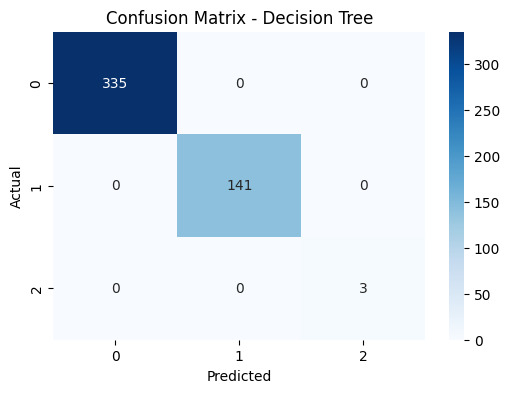

In [22]:
best_model_name = results.iloc[0]["Model"]

if best_model_name == "Logistic Regression":
    best_pred = y_pred_lr
elif best_model_name == "Decision Tree":
    best_pred = y_pred_dt
else:
    best_pred = y_pred_rf

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [23]:
rf_model = rf_pipeline.named_steps["model"]
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importances


,feature,importance
4,sugar,0.191426
15,sugar_pct_meal_limit,0.158705
7,cholesterol,0.151839
11,sat_fat_pct_daily,0.124650
10,cholesterol_pct_daily,0.122697
2,sat_fat,0.113134
12,fat_pct_daily,0.030223
1,fat,0.024399
5,protein,0.021515
3,carbs,0.017122


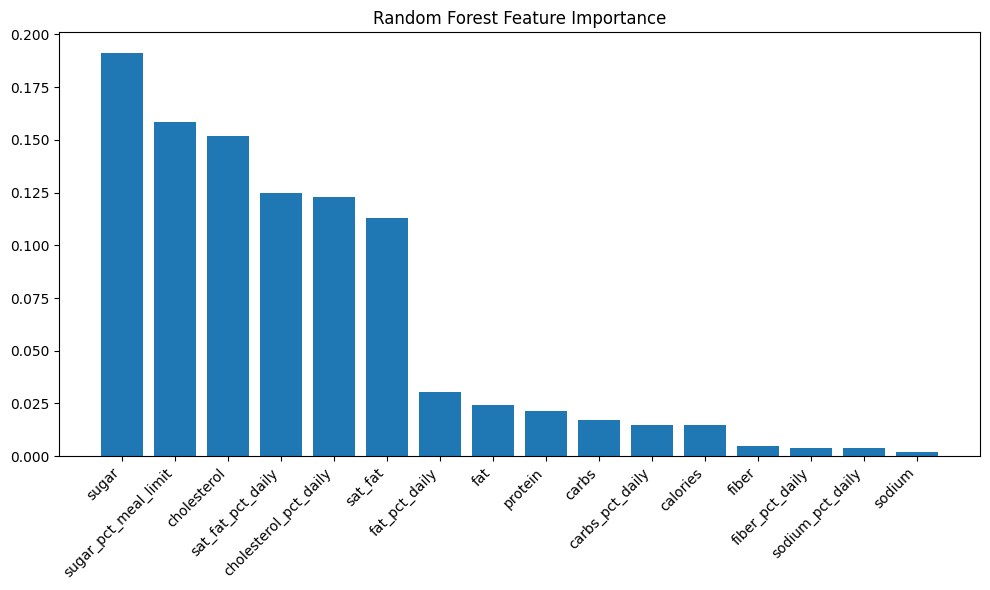

In [24]:
plt.figure(figsize=(10, 6))
plt.bar(importances["feature"], importances["importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


## 12. Create Chatbot-style Food Summary

In [25]:
def evaluate_food_item(row):
    messages = []

    if row["sodium"] >= 360:
        messages.append("โซเดียมค่อนข้างสูง")
    if row["cholesterol"] >= 60:
        messages.append("โคเลสเตอรอลค่อนข้างสูง")
    if row["sugar"] >= DGA_ADDED_SUGAR_LIMIT_PER_MEAL:
        messages.append("น้ำตาลถึงหรือเกินเกณฑ์ต่อมื้อ")
    if row["sat_fat"] >= 0.30 * THAI_RDI_SAT_FAT:
        messages.append("ไขมันอิ่มตัวค่อนข้างสูง")

    if not messages:
        messages.append("ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น")

    return " | ".join(messages)

df_model["chatbot_summary"] = df_model.apply(evaluate_food_item, axis=1)

preview_cols = ["risk_level", "chatbot_summary"]
if "food_name" in df_model.columns:
    preview_cols = ["food_name"] + preview_cols

df_model[preview_cols].head(10)


,food_name,risk_level,chatbot_summary
0,cream cheese,Low,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น
1,neufchatel cheese,Medium,โคเลสเตอรอลค่อนข้างสูง | ไขมันอิ่มตัวค่อนข้างสูง
2,requeijao cremoso light catupiry,Low,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น
3,ricotta cheese,Low,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น
4,cream cheese low fat,Low,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น
5,cream cheese fat free,Low,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น
6,gruyere cheese,Low,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น
7,cheddar cheese,Low,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น
8,parmesan cheese,Low,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น
9,romano cheese,Low,ยังไม่พบตัวชี้วัดที่เกินเกณฑ์เบื้องต้น


## 13. Save Outputs

In [26]:
os.makedirs("../outputs", exist_ok=True)

df_model.to_csv("../outputs/food_dataset_with_risk.csv", index=False)
results.to_csv("../outputs/model_results.csv", index=False)
importances.to_csv("../outputs/feature_importance.csv", index=False)

print("saved:")
print("- ../outputs/food_dataset_with_risk.csv")
print("- ../outputs/model_results.csv")
print("- ../outputs/feature_importance.csv")


saved:
- ../outputs/food_dataset_with_risk.csv
- ../outputs/model_results.csv
- ../outputs/feature_importance.csv


## 14. Final Summary

### Data Preparation
- รวม dataset หลักของอาหาร
- map ชื่อคอลัมน์ให้เป็นมาตรฐาน
- ลบข้อมูลซ้ำ
- แปลงข้อมูลเป็น numeric
- เติม missing values ด้วย median
- สร้าง feature ใหม่จากเกณฑ์มาตรฐานโภชนาการ

### Modelling
- สร้าง `risk_level` แบบ rule-based
- ใช้เป็น target สำหรับ baseline classification
- ทดลอง Logistic Regression, Decision Tree และ Random Forest
- เปรียบเทียบผลด้วย Accuracy และ Classification Report

### Output
ผลลัพธ์ถูกบันทึกไว้ใน `../outputs/` เพื่อใช้ต่อในระบบถามตอบหรือ chatbot
